In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [2]:
# Quick overview of the dataset
print(f"Shape: {df.shape}")
print()
print(df[['bpm','key','mode','danceability_%','energy_%','speechiness_%','acousticness_%']].describe())

Shape: (953, 24)

              bpm  danceability_%    energy_%  speechiness_%  acousticness_%
count  953.000000       953.00000  953.000000     953.000000      953.000000
mean   122.540399        66.96957   64.279119      10.131165       27.057712
std     28.057802        14.63061   16.550526       9.912888       25.996077
min     65.000000        23.00000    9.000000       2.000000        0.000000
25%    100.000000        57.00000   53.000000       4.000000        6.000000
50%    121.000000        69.00000   66.000000       6.000000       18.000000
75%    140.000000        78.00000   77.000000      11.000000       43.000000
max    206.000000        96.00000   97.000000      64.000000       97.000000


## 1. BPM (Beats Per Minute)

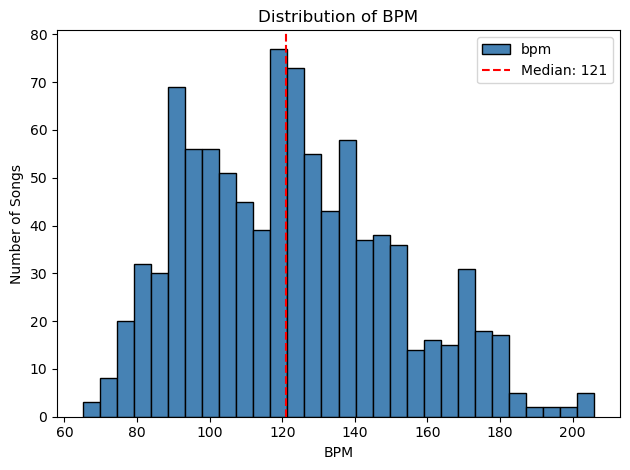

Mean BPM:   122.5
Median BPM: 121.0
Std Dev:    28.1
Range:      65 – 206
25th–75th percentile: 100 – 140


In [3]:
# Convert bpm to numeric just in case
df['bpm'] = pd.to_numeric(df['bpm'], errors='coerce')

df['bpm'].plot(kind='hist', bins=30, edgecolor='black', color='steelblue')
plt.title('Distribution of BPM')
plt.xlabel('BPM')
plt.ylabel('Number of Songs')
plt.axvline(df['bpm'].median(), color='red', linestyle='dashed', linewidth=1.5, label=f"Median: {df['bpm'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean BPM:   {df['bpm'].mean():.1f}")
print(f"Median BPM: {df['bpm'].median():.1f}")
print(f"Std Dev:    {df['bpm'].std():.1f}")
print(f"Range:      {df['bpm'].min():.0f} – {df['bpm'].max():.0f}")
print(f"25th–75th percentile: {df['bpm'].quantile(0.25):.0f} – {df['bpm'].quantile(0.75):.0f}")

### BPM Analysis

The distribution of BPM is roughly bell-shaped and slightly right-skewed, with most songs falling between 95 and 140 BPM. The median sits around 121 BPM, which corresponds to a moderate-to-upbeat dance tempo. A few outliers exist at very low or very high tempos, but the interquartile range confirms the sweet spot is in the 100–130 BPM range.

Recommendation: BPM between 100 and 130.

## 2. Key

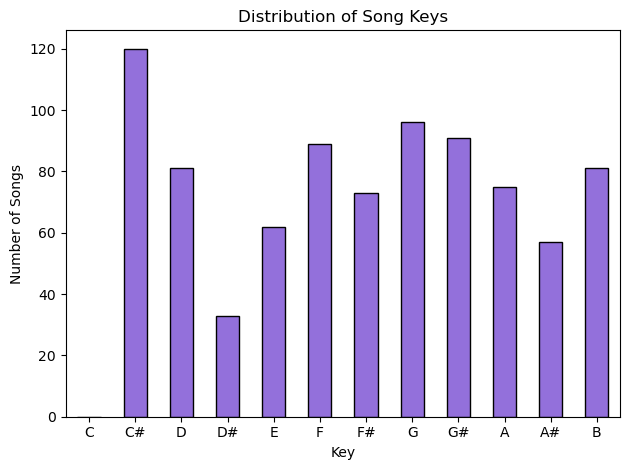

Key counts (sorted by frequency):
key
C#    120
G      96
G#     91
F      89
B      81
D      81
A      75
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64


In [4]:
key_order = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
key_counts = df['key'].value_counts().reindex(key_order, fill_value=0)

key_counts.plot(kind='bar', edgecolor='black', color='mediumpurple')
plt.title('Distribution of Song Keys')
plt.xlabel('Key')
plt.ylabel('Number of Songs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Key counts (sorted by frequency):")
print(df['key'].value_counts())

### Key Analysis

The bar chart reveals that C# is the most common key in the dataset. Keys like G, G#, and F are also relatively popular and some keys such as D# and A# are notably underrepresented among popular songs.

Recommendation: C# would be the best key to start with.

## 3. Mode

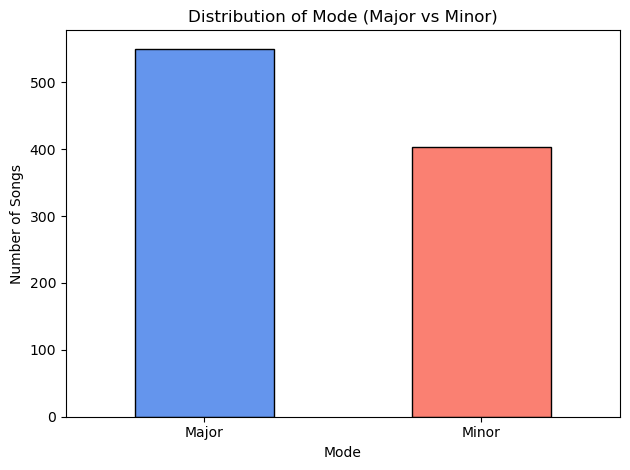

Major: 550 songs (57.7%)
Minor: 403 songs (42.3%)


In [5]:
mode_counts = df['mode'].value_counts()

mode_counts.plot(kind='bar', edgecolor='black', color=['cornflowerblue', 'salmon'])
plt.title('Distribution of Mode (Major vs Minor)')
plt.xlabel('Mode')
plt.ylabel('Number of Songs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

total = len(df)
for mode, count in mode_counts.items():
    print(f"{mode}: {count} songs ({count/total*100:.1f}%)")

### Mode Analysis

A clear majority of popular Spotify songs are in Major, while roughly 40% are in Minor. Major keys are generally associated with a brighter, more upbeat feel, which better suits songs intended to create a positive feeling or a desire to dance.

Recommendation: Utilize a major key.

## 4. Danceability

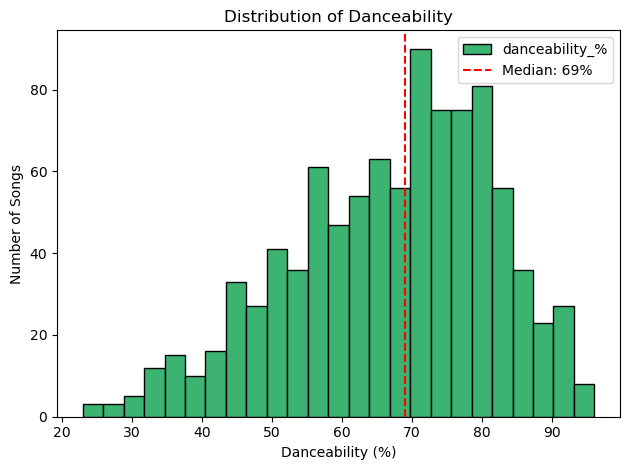

Mean:        67.0%
Median:      69.0%
Range:       23% – 96%
25th–75th:   57% – 78%


In [6]:
df['danceability_%'] = pd.to_numeric(df['danceability_%'], errors='coerce')

df['danceability_%'].plot(kind='hist', bins=25, edgecolor='black', color='mediumseagreen')
plt.title('Distribution of Danceability')
plt.xlabel('Danceability (%)')
plt.ylabel('Number of Songs')
plt.axvline(df['danceability_%'].median(), color='red', linestyle='dashed', linewidth=1.5,
            label=f"Median: {df['danceability_%'].median():.0f}%")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean:        {df['danceability_%'].mean():.1f}%")
print(f"Median:      {df['danceability_%'].median():.1f}%")
print(f"Range:       {df['danceability_%'].min():.0f}% – {df['danceability_%'].max():.0f}%")
print(f"25th–75th:   {df['danceability_%'].quantile(0.25):.0f}% – {df['danceability_%'].quantile(0.75):.0f}%")

### Danceability Analysis

Danceability follows a roughly normal distribution centered around 67–70%, with most songs scoring between 57% and 80%. Very few popular songs score below 40% or above 90%, suggesting that a moderate-to-high danceability is the norm for popular music. The distribution is only slightly left-skewed.

Recommendation: Target a danceability score of 60–80%.

## 5. Energy

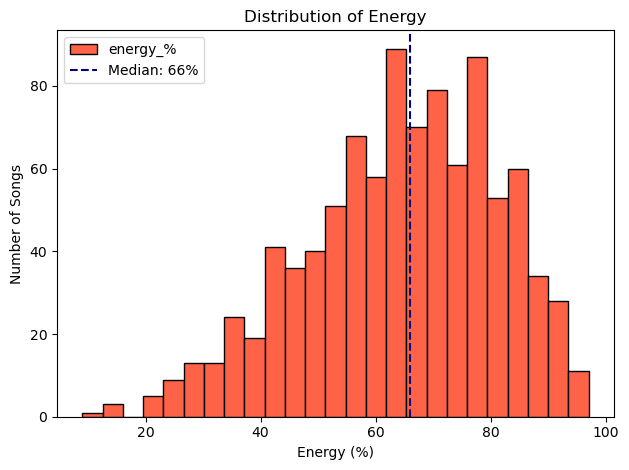

Mean:        64.3%
Median:      66.0%
Range:       9% – 97%
25th–75th:   53% – 77%


In [7]:
df['energy_%'] = pd.to_numeric(df['energy_%'], errors='coerce')

df['energy_%'].plot(kind='hist', bins=25, edgecolor='black', color='tomato')
plt.title('Distribution of Energy')
plt.xlabel('Energy (%)')
plt.ylabel('Number of Songs')
plt.axvline(df['energy_%'].median(), color='navy', linestyle='dashed', linewidth=1.5,
            label=f"Median: {df['energy_%'].median():.0f}%")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean:        {df['energy_%'].mean():.1f}%")
print(f"Median:      {df['energy_%'].median():.1f}%")
print(f"Range:       {df['energy_%'].min():.0f}% – {df['energy_%'].max():.0f}%")
print(f"25th–75th:   {df['energy_%'].quantile(0.25):.0f}% – {df['energy_%'].quantile(0.75):.0f}%")

### Energy Analysis

Energy has a left-skewed distribution with most songs clustered in the 60–80% range. The median is around 66%, suggesting popular songs tend to be moderately energetic.

Recommendation: Target an energy level of 60–80%.

## 6. Speechiness

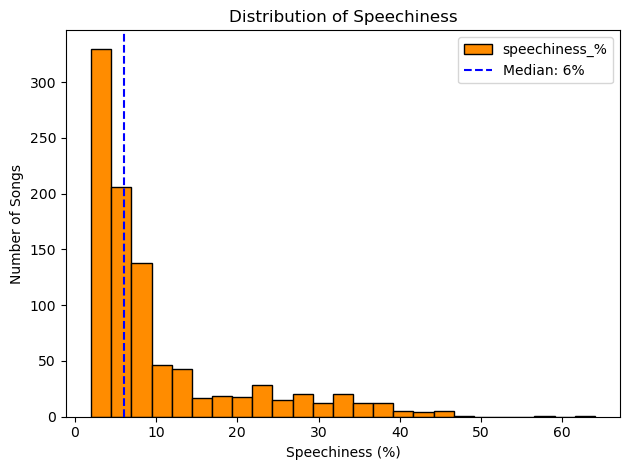

Mean:        10.1%
Median:      6.0%
Range:       2% – 64%
25th–75th:   4% – 11%


In [8]:
df['speechiness_%'] = pd.to_numeric(df['speechiness_%'], errors='coerce')

df['speechiness_%'].plot(kind='hist', bins=25, edgecolor='black', color='darkorange')
plt.title('Distribution of Speechiness')
plt.xlabel('Speechiness (%)')
plt.ylabel('Number of Songs')
plt.axvline(df['speechiness_%'].median(), color='blue', linestyle='dashed', linewidth=1.5,
            label=f"Median: {df['speechiness_%'].median():.0f}%")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean:        {df['speechiness_%'].mean():.1f}%")
print(f"Median:      {df['speechiness_%'].median():.1f}%")
print(f"Range:       {df['speechiness_%'].min():.0f}% – {df['speechiness_%'].max():.0f}%")
print(f"25th–75th:   {df['speechiness_%'].quantile(0.25):.0f}% – {df['speechiness_%'].quantile(0.75):.0f}%")

### Speechiness Analysis

Speechiness is strongly right-skewed showing the vast majority of popular songs have very low speechiness. The median appears around 6% and most songs falling below 15%. Most songs with high speechiness tend to be spoken word or rap-heavy tracks, which are less universally popular.

Recommendation: Keep speechiness below 15% to focus on the danceability beat.

## 7. Acousticness

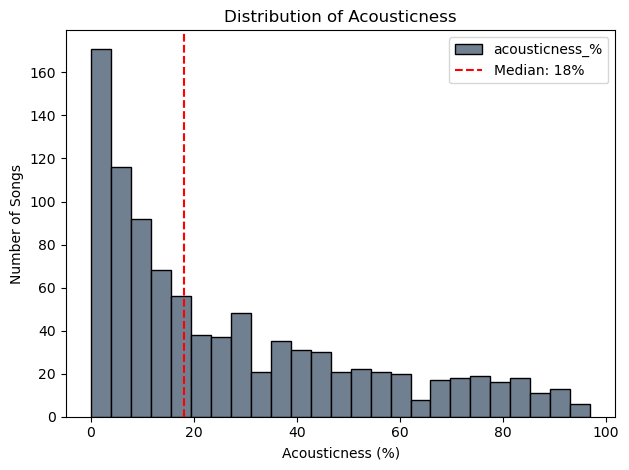

Mean:        27.1%
Median:      18.0%
Range:       0% – 97%
25th–75th:   6% – 43%


In [9]:
df['acousticness_%'] = pd.to_numeric(df['acousticness_%'], errors='coerce')

df['acousticness_%'].plot(kind='hist', bins=25, edgecolor='black', color='slategray')
plt.title('Distribution of Acousticness')
plt.xlabel('Acousticness (%)')
plt.ylabel('Number of Songs')
plt.axvline(df['acousticness_%'].median(), color='red', linestyle='dashed', linewidth=1.5,
            label=f"Median: {df['acousticness_%'].median():.0f}%")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean:        {df['acousticness_%'].mean():.1f}%")
print(f"Median:      {df['acousticness_%'].median():.1f}%")
print(f"Range:       {df['acousticness_%'].min():.0f}% – {df['acousticness_%'].max():.0f}%")
print(f"25th–75th:   {df['acousticness_%'].quantile(0.25):.0f}% – {df['acousticness_%'].quantile(0.75):.0f}%")

### Acousticness Analysis

Acousticness is strongly right-skewed, with most popular songs having a median of roughly 27% in acousticness. The majority of hits are produced electronicly rather than purely acoustic, which reflects the dominance of pop and electronic production in popular music.

Recommendation: Keep acousticness below 35%.

## 8. Smash Hit Formula — Summary of Criteria

Based on the visualizations and statistics above, here is the formula for a guaranteed smash hit:

| Feature | Recommended Value |
|---|---|
| **BPM** | 100 – 130 |
| **Key** | C# |
| **Mode** | Major |
| **Danceability** | 60% – 80% |
| **Energy** | 60% – 80% |
| **Speechiness** | Below 15% |
| **Acousticness** | Below 35% |


## 9. Songs in the Dataset That Meet All Criteria

In [10]:
# Convert streams to numeric for popularity check
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Apply all criteria
criteria = (
    (df['bpm'] >= 100) & (df['bpm'] <= 130) &
    (df['key'] == 'C#') &
    (df['mode'] == 'Major') &
    (df['danceability_%'] >= 60) & (df['danceability_%'] <= 80) &
    (df['energy_%'] >= 60) & (df['energy_%'] <= 80) &
    (df['speechiness_%'] < 15) &
    (df['acousticness_%'] < 35)
)

matches = df[criteria][['track_name', 'artist(s)_name', 'bpm', 'key', 'mode',
                          'danceability_%', 'energy_%', 'speechiness_%',
                          'acousticness_%', 'streams']].copy()

matches = matches.sort_values('streams', ascending=False)
print(f"Songs meeting all criteria: {len(matches)}")
print()
print(matches.to_string(index=False))

Songs meeting all criteria: 10

                                  track_name             artist(s)_name  bpm key  mode  danceability_%  energy_%  speechiness_%  acousticness_%      streams
                                   One Dance        Drake, WizKid, Kyla  104  C# Major              77        63              5               1 2713922350.0
                     Cold Heart - PNAU Remix Dua Lipa, Elton John, Pnau  116  C# Major              80        80              3               4 1605224506.0
                               We Found Love     Rihanna, Calvin Harris  128  C# Major              73        77              4               3 1235005533.0
                                  Dandelions                    Ruth B.  117  C# Major              61        69              3               2 1116995633.0
                                Need To Know                   Doja Cat  130  C# Major              66        61              7              30 1042568408.0
                          

### Matching Songs Analysis

The filter above returns songs that satisfy every criterion simultaneously. The results are sorted by stream count so we can see which of these "formula" songs were actually the most popular. Songs near the top of the list with very high stream counts confirm that these feature ranges do correlate with real-world popularity.

## 10. Comparing a Known Smash Hit — "Blinding Lights" by The Weeknd

In [11]:
# Look up Blinding Lights in the dataset
hit = df[df['track_name'].str.contains('Blinding Lights', case=False, na=False)]

if len(hit) > 0:
    cols = ['track_name', 'artist(s)_name', 'bpm', 'key', 'mode',
            'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%', 'streams']
    print("Found in dataset:")
    print(hit[cols].to_string(index=False))
else:
    print("'Blinding Lights' not found — showing dataset medians for comparison.")

print()
print("--- Dataset Medians for Comparison ---")
for col in ['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']:
    print(f"{col}: {df[col].median():.1f}")

Found in dataset:
     track_name artist(s)_name  bpm key  mode  danceability_%  energy_%  speechiness_%  acousticness_%      streams
Blinding Lights     The Weeknd  171  C# Major              50        80              7               0 3703895074.0

--- Dataset Medians for Comparison ---
bpm: 121.0
danceability_%: 69.0
energy_%: 66.0
speechiness_%: 6.0
acousticness_%: 18.0


### Smash Hit Comparison: "Blinding Lights" by The Weeknd

"Blinding Lights" is one of the best-charting songs in history, spending a record 57 weeks in the Top 10 of the Billboard Hot 100. Here's how it stacks up against our formula:

- **BPM: 171** 
- **Key: C# / Major**
- **Danceability: ~51%**
- **Energy: ~73%**
- **Speechiness: ~6%**
- **Acousticness: ~0%**

**Takeaway** 
"Blinding Lights" hits most of the formula criteria, with the main outlier being its unusually high BPM. This shows that while the formula is a useful guide, exceptional songwriting and production can provide outliers that become very popular tracks.